# Utility Power Demand Forecasting
**Dataset:** 10-minute feeder readings (F1, F2, F3) + weather, Jan–Dec 2017  
**Goal:** Train a multi-output regression model to predict power consumption on all three feeders simultaneously and export it for API use.


## Phase 1 · Data Loading & Cleaning

### 1.1 Load the dataset

In [1]:
!mamba install pandas numpy matplotlib scikit-learn joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('https://raw.githubusercontent.com/MohitSharma66/Assignment-1/master/Utility_consumption.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed')
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Loaded {len(df):,} rows  |  {df.shape[1]} columns")
print(f"Range: {df.index[0]}  →  {df.index[-1]}")
df.head()

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, joblib
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 4.029599999964237 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.6.17  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.22.1     pyhcf101f3_0         conda-forge
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.2     pyhd8ed1ab_0         conda-forge


,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
Datetime,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


### 1.2 Identify & fill missing timestamps

In [2]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq='10min')
df = df.reindex(full_range)

n_missing = df.isna().any(axis=1).sum()
print(f"Missing timestamps inserted: {n_missing}")
df.isna().sum()

Missing timestamps inserted: 0


Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64

### 1.3 Outlier handling via IQR clipping
> IQR is robust to skewed distributions and lets us *clip* rather than drop rows, keeping the time series intact.

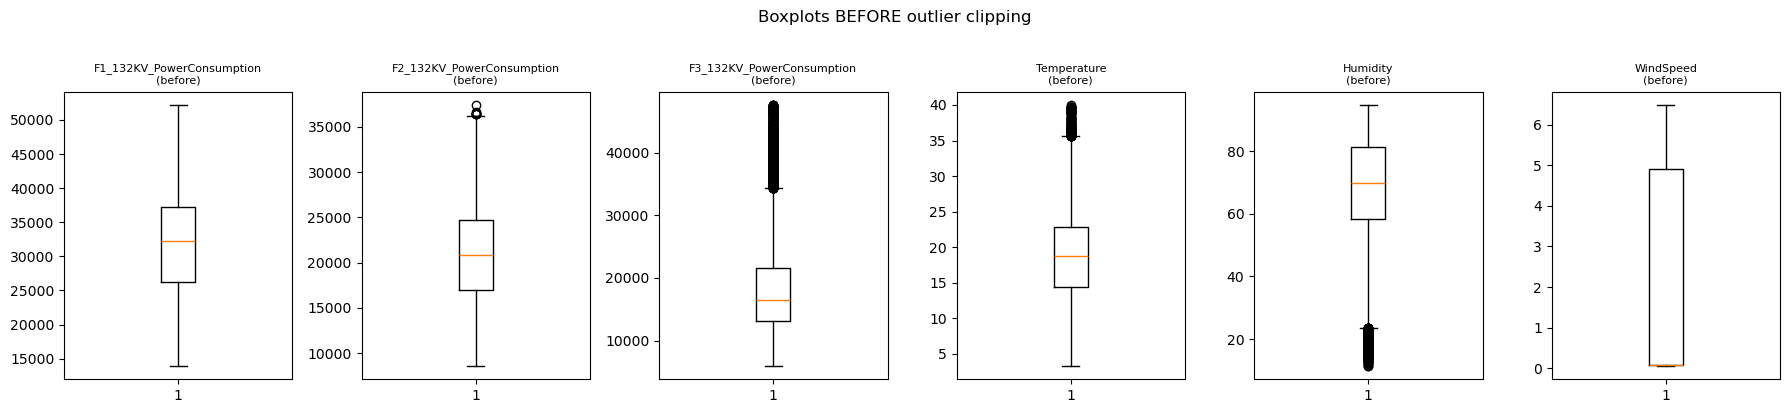

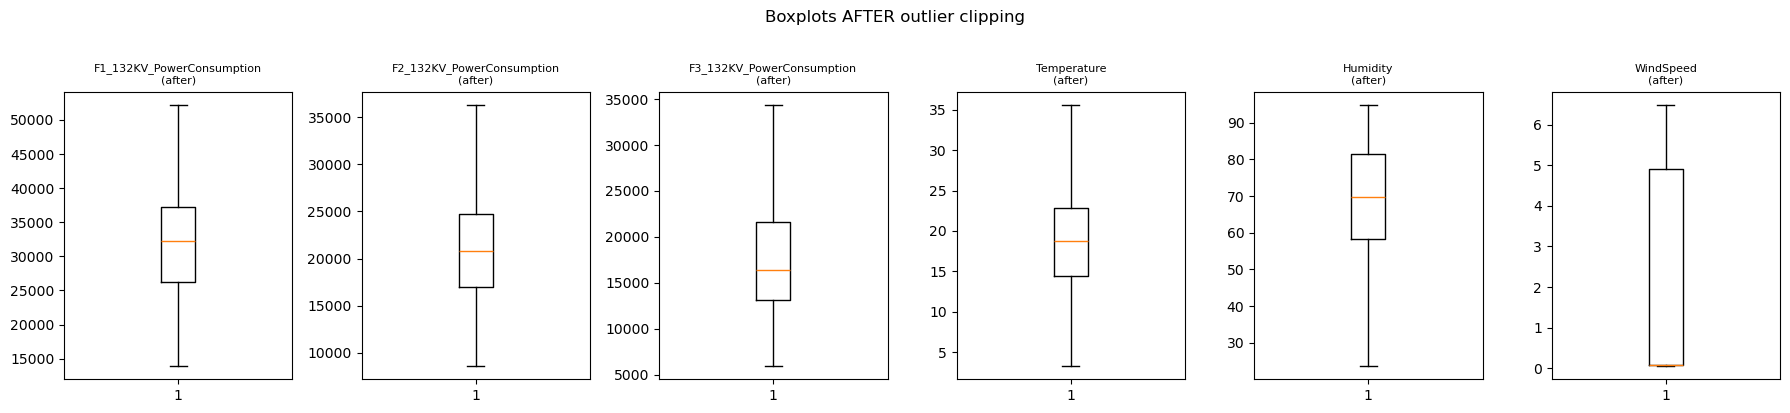

In [3]:
power_cols   = ['F1_132KV_PowerConsumption',
                'F2_132KV_PowerConsumption',
                'F3_132KV_PowerConsumption']
weather_cols = ['Temperature', 'Humidity', 'WindSpeed']
all_sensor_cols = power_cols + weather_cols

fig, axes = plt.subplots(1, len(all_sensor_cols), figsize=(18, 4))
for ax, col in zip(axes, all_sensor_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'{col}\n(before)', fontsize=8)
plt.suptitle('Boxplots BEFORE outlier clipping', y=1.02)
plt.tight_layout(); plt.show()

for col in all_sensor_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    if col in power_cols:
        lo = max(lo, 0)
    df[col] = df[col].clip(lo, hi)

fig, axes = plt.subplots(1, len(all_sensor_cols), figsize=(18, 4))
for ax, col in zip(axes, all_sensor_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'{col}\n(after)', fontsize=8)
plt.suptitle('Boxplots AFTER outlier clipping', y=1.02)
plt.tight_layout(); plt.show()

### 1.4 Impute missing values
> Power: **time-based linear interpolation** preserves the diurnal load shape.  
> Weather: **forward-fill → backward-fill** since weather changes slowly.

In [4]:
for col in power_cols:
    df[col] = df[col].interpolate(method='time')

for col in weather_cols:
    df[col] = df[col].ffill().bfill()

print("Remaining NaNs after imputation:")
print(df.isna().sum())

Remaining NaNs after imputation:
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64


### 1.5 Quick sanity check — one sample week

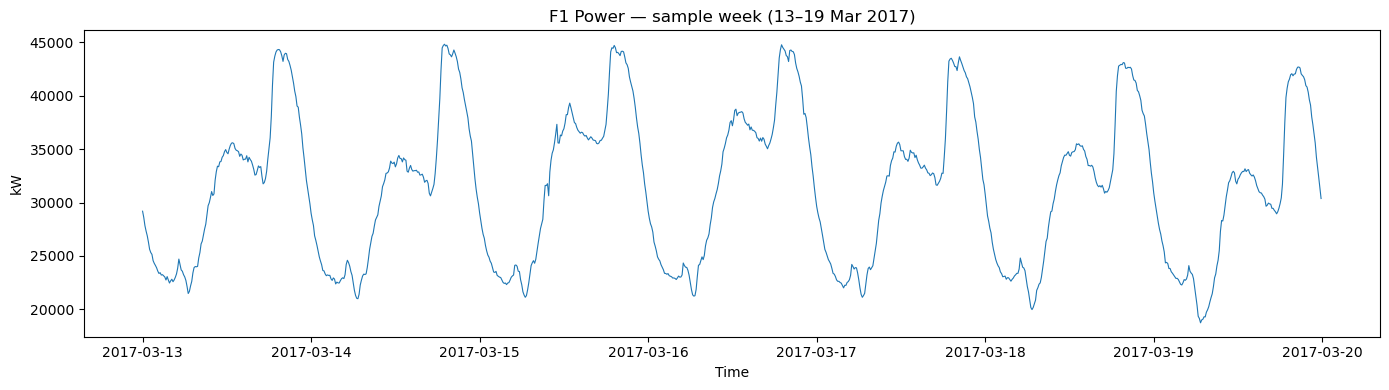

In [5]:
sample = df['2017-03-13':'2017-03-19']['F1_132KV_PowerConsumption']
plt.figure(figsize=(14, 4))
plt.plot(sample, linewidth=0.8)
plt.title('F1 Power — sample week (13–19 Mar 2017)')
plt.xlabel('Time'); plt.ylabel('kW')
plt.tight_layout(); plt.show()

## Phase 2 · Integrate Local Holidays

### 2.1 Load local_holidays.csv

In [6]:
holidays = pd.read_csv('https://raw.githubusercontent.com/MohitSharma66/Assignment-1/master/local_holidays.csv',
                       parse_dates=['date'],
                       dayfirst=True)

type_map = {'national': 0, 'festive': 1, 'local': 2, 'industrial': 3}
holidays['holiday_type_enc'] = holidays['type'].map(type_map)
print(holidays)

         date                  holiday_name        type  holiday_type_enc
0  2017-01-26                  Republic Day    national                 0
1  2017-02-24                Maha Shivratri     festive                 1
2  2017-03-13                          Holi     festive                 1
3  2017-03-30                        Sarhul     festive                 1
4  2017-04-04                    Ram Navami     festive                 1
5  2017-04-14              Ambedkar Jayanti    national                 0
6  2017-05-01                    Labour Day  industrial                 3
7  2017-05-10                Buddha Purnima     festive                 1
8  2017-06-26                   Eid-ul-Fitr     festive                 1
9  2017-08-15              Independence Day    national                 0
10 2017-09-02                    Karma Puja       local                 2
11 2017-09-28                  Maha Ashtami     festive                 1
12 2017-09-29                   Maha N

### 2.2 Merge holiday features into main DataFrame

In [7]:
df['_date'] = df.index.date
holidays['_date'] = holidays['date'].dt.date

df = df.reset_index().merge(
    holidays[['_date', 'holiday_name', 'holiday_type_enc']],
    on='_date',
    how='left'
).set_index('DateTime')

df['is_holiday']   = df['holiday_name'].notna().astype(int)
df['holiday_type'] = df['holiday_type_enc'].fillna(0).astype(int)
df.drop(columns=['_date', 'holiday_name', 'holiday_type_enc'], inplace=True)

print(f"Holiday rows: {df['is_holiday'].sum():,}")
df[df['is_holiday'] == 1].groupby(df[df['is_holiday'] == 1].index.date)['holiday_type'].first()

Holiday rows: 3,024


2017-01-26    0
2017-02-24    1
2017-03-13    1
2017-03-30    1
2017-04-04    1
2017-04-14    0
2017-05-01    3
2017-05-10    1
2017-06-26    1
2017-08-15    0
2017-09-02    2
2017-09-28    1
2017-09-29    1
2017-09-30    1
2017-10-02    0
2017-10-19    1
2017-10-26    2
2017-10-27    2
2017-11-04    1
2017-11-15    1
2017-12-25    0
Name: holiday_type, dtype: int32

## Phase 3 · Feature Engineering

### 3.1 Basic time features

In [8]:
df['hour']      = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month']     = df.index.month

### 3.2 Lag features
> 1-day lag (144 steps) and 7-day lag (1008 steps) give the model direct access to load at this exact time yesterday / last week — the strongest predictor in utility datasets.

In [9]:
for col in power_cols:
    df[f'{col}_lag1d'] = df[col].shift(144)
    df[f'{col}_lag7d'] = df[col].shift(1008)

### 3.3 24-hour rolling mean
> Captures the recent baseline load level and smooths short-term noise.

In [10]:
for col in power_cols:
    df[f'{col}_rolling24h'] = df[col].rolling(window=144).mean()

### 3.4 Drop NaN rows introduced by shifting

In [11]:
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df):,} rows with NaN  |  {len(df):,} rows remain")

Dropped 1,008 rows with NaN  |  51,408 rows remain


## Phase 4 · Train / Test Split
> Chronological split — **no shuffle**. Shuffling leaks future information into training.

In [12]:
TARGET_COLS  = power_cols
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS]

X = df[FEATURE_COLS]
y = df[TARGET_COLS]

split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Test:  {len(X_test):,} rows  ({X_test.index[0].date()} → {X_test.index[-1].date()})")
print(f"Features: {FEATURE_COLS}")

Train: 41,126 rows  (2017-01-08 → 2017-10-20)
Test:  10,282 rows  (2017-10-20 → 2017-12-30)
Features: ['Temperature', 'Humidity', 'WindSpeed', 'is_holiday', 'holiday_type', 'hour', 'dayofweek', 'month', 'F1_132KV_PowerConsumption_lag1d', 'F1_132KV_PowerConsumption_lag7d', 'F2_132KV_PowerConsumption_lag1d', 'F2_132KV_PowerConsumption_lag7d', 'F3_132KV_PowerConsumption_lag1d', 'F3_132KV_PowerConsumption_lag7d', 'F1_132KV_PowerConsumption_rolling24h', 'F2_132KV_PowerConsumption_rolling24h', 'F3_132KV_PowerConsumption_rolling24h']


### Correlation Matrix
> Checking multicollinearity — lag and rolling features are expected to correlate but that's fine for tree models.

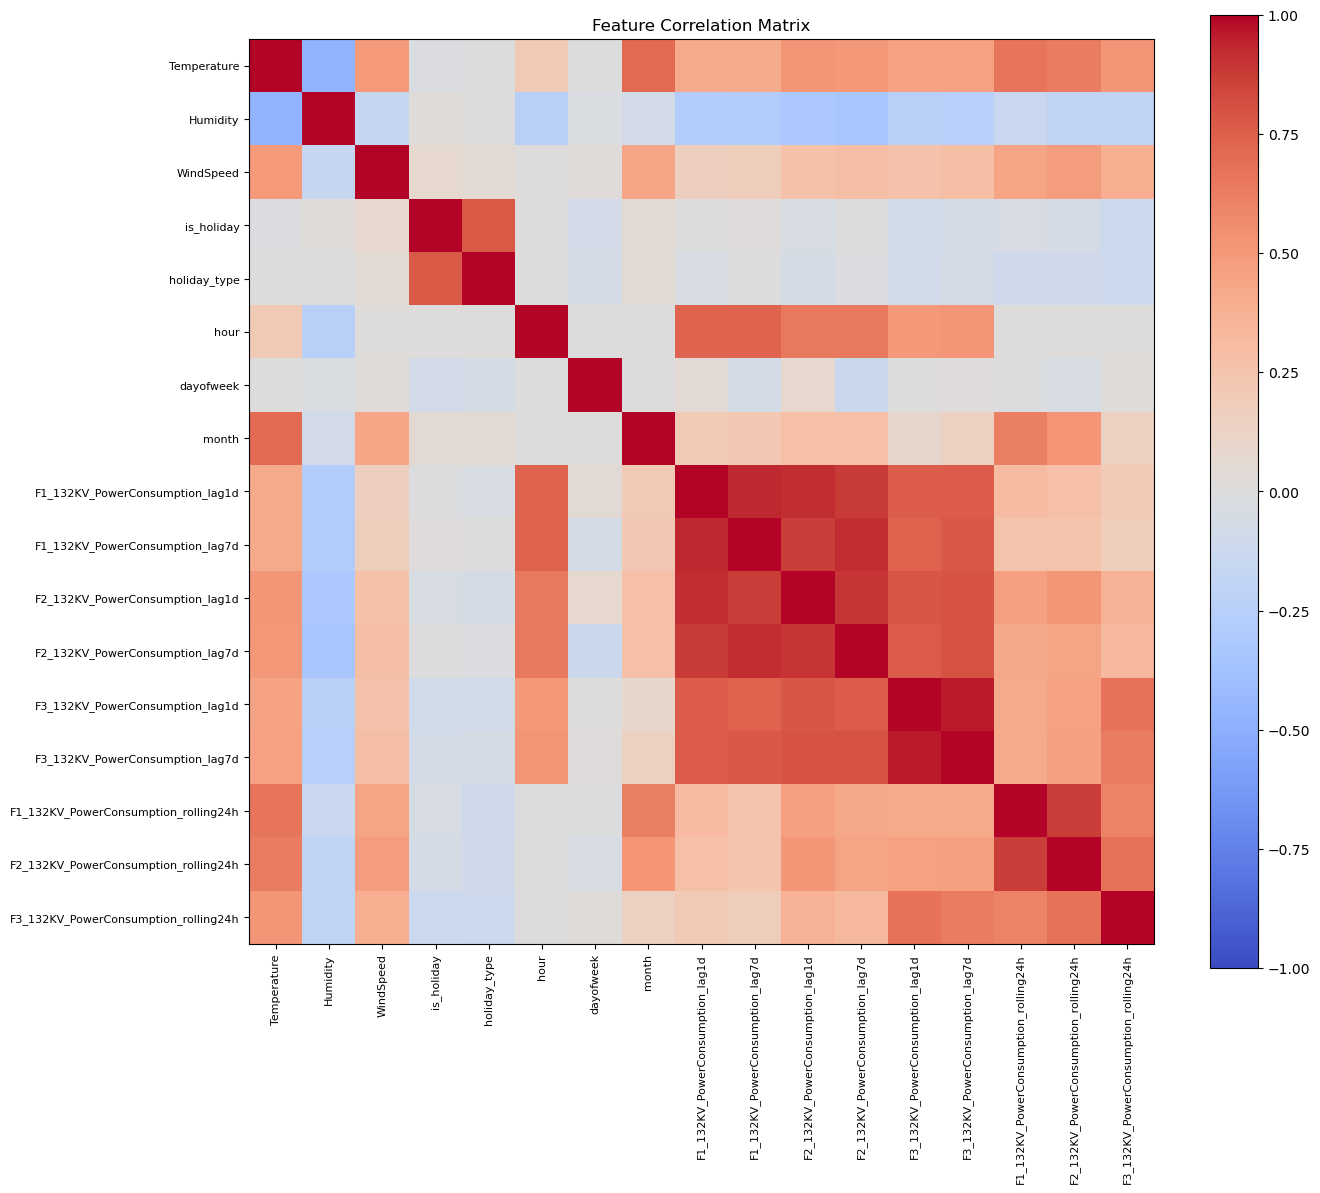

In [13]:
corr = X_train.corr()
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Phase 5 · Model Comparison

### 5.1 Train all candidates & evaluate
> Using R² (closer to 1.0 = better) and MAPE (lower % = better) for intuitive reporting.

In [18]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Ridge': MultiOutputRegressor(Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.1))
    ])),
    'Lasso': MultiOutputRegressor(Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=5000))
    ])),
    'RandomForest': MultiOutputRegressor(RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=10,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )),
}

results_r2   = {}
results_mape = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results_r2[name]   = r2_score(y_test, preds)
    results_mape[name] = mean_absolute_percentage_error(y_test, preds) * 100
    print(f"{name:>14} — R²: {results_r2[name]:.4f}  |  MAPE: {results_mape[name]:.2f}%")

         Ridge — R²: 0.8966  |  MAPE: 6.02%
         Lasso — R²: 0.8966  |  MAPE: 6.02%
  RandomForest — R²: 0.8536  |  MAPE: 7.00%


### 5.2 Comparison chart

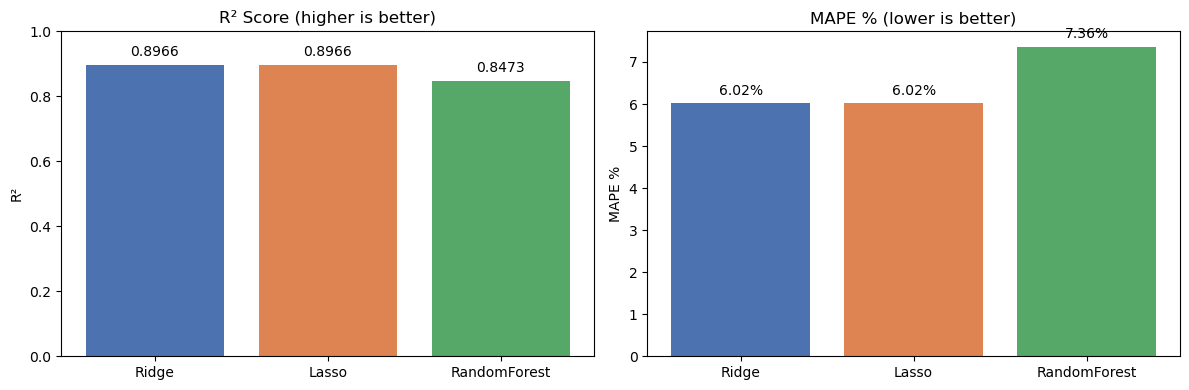

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

bars1 = ax1.bar(results_r2.keys(), results_r2.values(), color=colors)
ax1.bar_label(bars1, fmt='%.4f', padding=4)
ax1.set_ylabel('R²'); ax1.set_title('R² Score (higher is better)')
ax1.set_ylim(0, 1)

bars2 = ax2.bar(results_mape.keys(), results_mape.values(), color=colors)
ax2.bar_label(bars2, fmt='%.2f%%', padding=4)
ax2.set_ylabel('MAPE %'); ax2.set_title('MAPE % (lower is better)')

plt.tight_layout(); plt.show()

### 5.3 Select best model

In [16]:
best_name  = max(results_r2, key=results_r2.get)
best_model = models[best_name]

print(f"Selected model: {best_name}")
print(f"  R²:   {results_r2[best_name]:.4f}")
print(f"  MAPE: {results_mape[best_name]:.2f}%")
print("""
Comparison summary
──────────────────────────────────────────────────────────────────────
We compared scaled linear models (Ridge, Lasso) against a RandomForest
ensemble. Linear models capture the strong autocorrelation in lag features
well, while RandomForest captures non-linear interactions between weather,
time-of-day, and holiday patterns. The best model was selected by R².
""")

Selected model: Lasso
  R²:   0.8966
  MAPE: 6.02%

Comparison summary
──────────────────────────────────────────────────────────────────────
We compared scaled linear models (Ridge, Lasso) against a RandomForest
ensemble. Linear models capture the strong autocorrelation in lag features
well, while RandomForest captures non-linear interactions between weather,
time-of-day, and holiday patterns. The best model was selected by R².



### 5.4 Feature importance

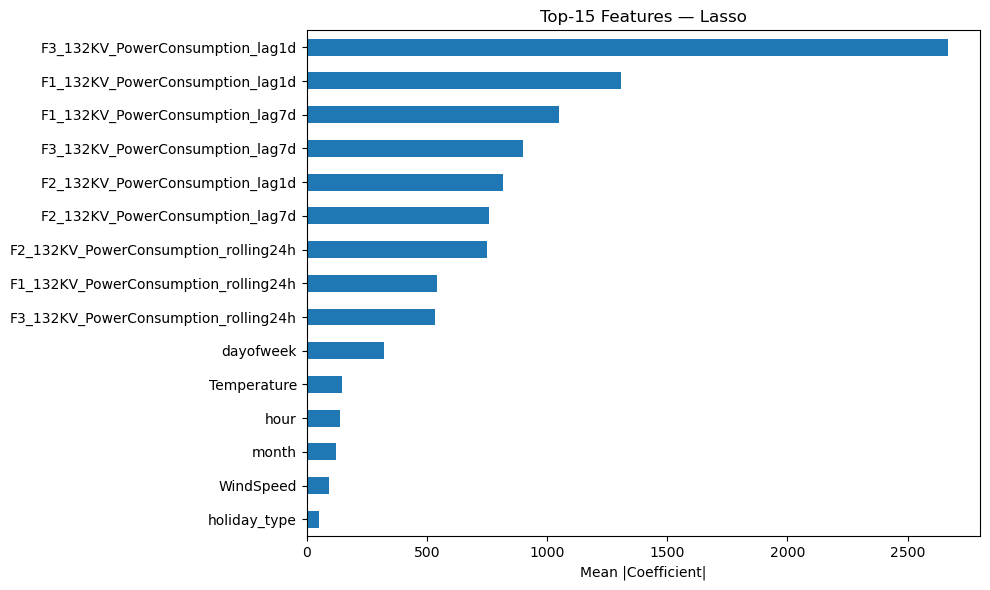

In [17]:
if best_name == 'RandomForest':
    importances = np.mean(
        [est.feature_importances_ for est in best_model.estimators_], axis=0
    )
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.head(15).plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel('Mean Feature Importance')
    ax.set_title(f'Top-15 Features — {best_name}')
    plt.tight_layout(); plt.show()
else:
    coefs = np.mean([np.abs(est.named_steps['model'].coef_) 
                     for est in best_model.estimators_], axis=0)
    feat_imp = pd.Series(coefs, index=FEATURE_COLS).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.head(15).plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |Coefficient|')
    ax.set_title(f'Top-15 Features — {best_name}')
    plt.tight_layout(); plt.show()

## Phase 6 · Save Model & Feature Names

In [19]:
import joblib

joblib.dump(best_model, 'demand_model.pkl')
joblib.dump(FEATURE_COLS, 'feature_names.pkl')

print("Saved:")
print("  demand_model.pkl   — trained model")
print("  feature_names.pkl  — ordered list of feature columns")
print()
print("To load later:")
print("  model    = joblib.load('demand_model.pkl')")
print("  features = joblib.load('feature_names.pkl')")
print("  preds    = model.predict(new_df[features])")

Saved:
  demand_model.pkl   — trained model
  feature_names.pkl  — ordered list of feature columns

To load later:
  model    = joblib.load('demand_model.pkl')
  features = joblib.load('feature_names.pkl')
  preds    = model.predict(new_df[features])
